# 유튜브 채널 분석 노트북

yt-dlp로 수집한 채널 데이터를 **댓글 텍스트 마이닝 · 조회수 시계열 · 영상 길이 · 제목/장르** 관점에서 분석합니다.

**실행 순서**
1. 먼저 터미널에서 데이터 수집:
   ```bash
   python collect.py "@지유개" --max-videos 100 --with-comments --comment-videos 20
   ```
2. 그다음 이 노트북을 위에서부터 실행하세요.


## 0. 준비 — 라이브러리 & 한글 폰트

In [1]:
import pandas as pd, numpy as np
from collections import Counter
import matplotlib.pyplot as plt
from matplotlib import font_manager
import koreatext as kt   # 같은 폴더의 유틸 모듈

FONT_PATH = kt.find_korean_font()
if FONT_PATH:
    font_manager.fontManager.addfont(FONT_PATH)
    plt.rcParams['font.family'] = font_manager.FontProperties(fname=FONT_PATH).get_name()
plt.rcParams['axes.unicode_minus'] = False
print('한글 폰트:', FONT_PATH)

한글 폰트: /System/Library/Fonts/AppleSDGothicNeo.ttc


## 1. 데이터 로드 & 파생 컬럼

In [2]:
df = pd.read_csv('data/videos.csv')
df['upload_date'] = pd.to_datetime(df['upload_date'].astype('Int64').astype(str),
                                   format='%Y%m%d', errors='coerce')
for c in ['duration','view_count','like_count','comment_count']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df['duration_min'] = df['duration']/60
df['title_len']    = df['title'].astype(str).str.len()
df['is_short']     = df['duration'] <= 60
df['like_rate']    = df['like_count']/df['view_count']
df = df.sort_values('upload_date')
df.head()

,id,title,upload_date,duration,view_count,like_count,comment_count,channel,channel_id,categories,tags,webpage_url,duration_min,title_len,is_short,like_rate
99,nn7l0eFEfKM,맥앤치즈 같이 먹었어요,2022-12-23,464,132193,1866,145,zziU & Ezzi,UCd-Ui_M4pAXhD1Xg8IyGebg,Pets & Animals,나홀로집에|나홀로집에 케빈 음식|맥앤치즈먹방|맥앤치즈asmr|크리스마스 음식|크리스...,https://www.youtube.com/watch?v=nn7l0eFEfKM,7.733333,12,False,0.014116
98,hr5GAUQPMNU,닭발 같이 먹었닭요,2023-01-08,414,457105,5842,377,zziU & Ezzi,UCd-Ui_M4pAXhD1Xg8IyGebg,Entertainment,닭발|닭발먹방|닭발asmr|닭발 먹방 asmr|지유개|zziudog|zziu&ezz...,https://www.youtube.com/watch?v=hr5GAUQPMNU,6.900000,10,False,0.012780
97,UMOKKtA1Dpw,버블티 같이 먹었어요,2023-01-19,559,677116,7822,538,zziU & Ezzi,UCd-Ui_M4pAXhD1Xg8IyGebg,Pets & Animals,버블티|버블티 먹방|버블티 asmr|시바견|시바견 먹방|지유개|zziu&ezzi|z...,https://www.youtube.com/watch?v=UMOKKtA1Dpw,9.316667,11,False,0.011552
96,2Jx32HY3cXM,호빵 같이 먹었호호,2023-01-29,506,227812,3204,233,zziU & Ezzi,UCd-Ui_M4pAXhD1Xg8IyGebg,Entertainment,호빵|호빵 먹방|삼립호빵|쑥호빵|피자호빵|호빵asmr|지유개|zziu&ezzi|zz...,https://www.youtube.com/watch?v=2Jx32HY3cXM,8.433333,10,False,0.014064
95,fFX2mRWx9xY,순대 같이 먹었어요 (죠스떡볶이와 이마트 찹쌀순대),2023-02-09,634,409907,5763,445,zziU & Ezzi,UCd-Ui_M4pAXhD1Xg8IyGebg,Entertainment,순대|순대먹방|떡볶이|떡볶이 먹방|죠스떡볶이|죠스떡볶이 먹방|순대 떡볶이|순대 떡볶...,https://www.youtube.com/watch?v=fFX2mRWx9xY,10.566667,28,False,0.014059


In [3]:
# 기초 통계
print('영상 수      :', len(df))
print('기간         :', df['upload_date'].min().date(), '~', df['upload_date'].max().date())
print('평균 조회수  :', int(df['view_count'].mean()))
print('평균 길이(분):', round(df['duration_min'].mean(),1))
print('숏폼 비율    :', f"{df['is_short'].mean()*100:.0f}%")
df[['view_count','duration_min','like_rate']].describe()

영상 수      : 100
기간         : 2022-12-23 ~ 2026-06-19
평균 조회수  : 226131
평균 길이(분): 10.3
숏폼 비율    : 0%


,view_count,duration_min,like_rate
count,1.000000e+02,100.000000,100.000000
mean,2.261310e+05,10.281500,0.019396
std,3.784083e+05,6.285269,0.005758
min,6.617000e+03,1.333333,0.008416
25%,5.160925e+04,8.145833,0.015860
50%,9.790250e+04,9.691667,0.018327
75%,2.309420e+05,11.308333,0.023240
max,2.662152e+06,63.933333,0.038374


## 2. 조회수 시계열
> yt-dlp의 조회수는 *수집 시점 누적값*입니다. 특정 영상의 시간별 곡선은 공개되지 않으므로 **업로드일 기준 집계**로 봅니다.

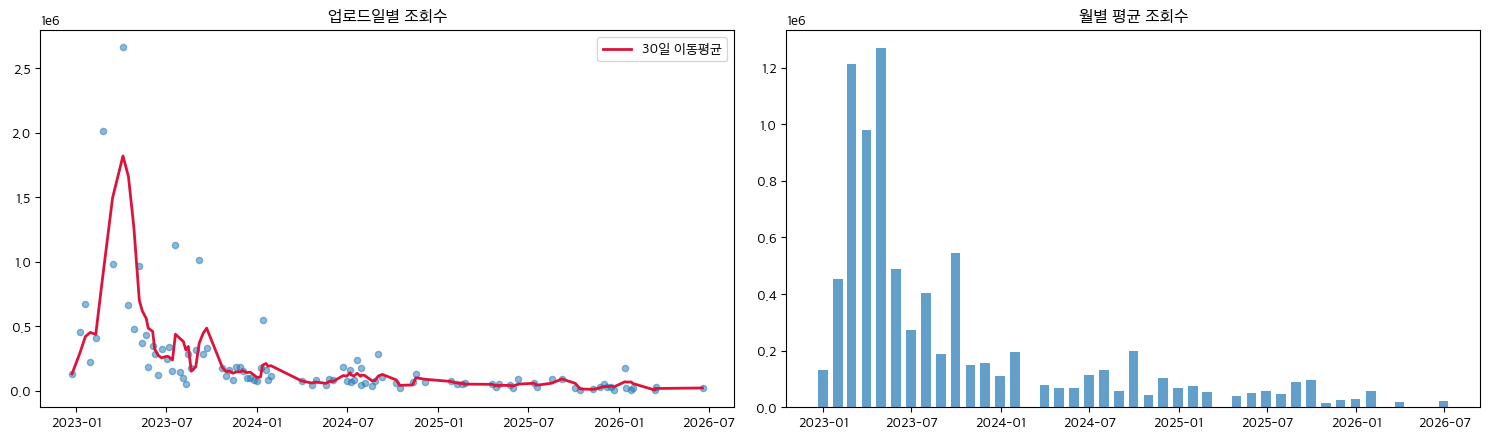

In [4]:
d = df.dropna(subset=['upload_date','view_count'])
fig, ax = plt.subplots(1,2, figsize=(15,4.5))
ax[0].scatter(d['upload_date'], d['view_count'], alpha=.5, s=20)
roll = d.set_index('upload_date')['view_count'].rolling('30D').mean()
ax[0].plot(roll.index, roll.values, 'crimson', lw=2, label='30일 이동평균')
ax[0].set_title('업로드일별 조회수'); ax[0].legend()
monthly = d.set_index('upload_date').resample('ME')['view_count'].agg(['mean','count'])
ax[1].bar(monthly.index, monthly['mean'], width=20, alpha=.7)
ax[1].set_title('월별 평균 조회수')
plt.tight_layout(); plt.show()

## 3. 영상 길이 분석

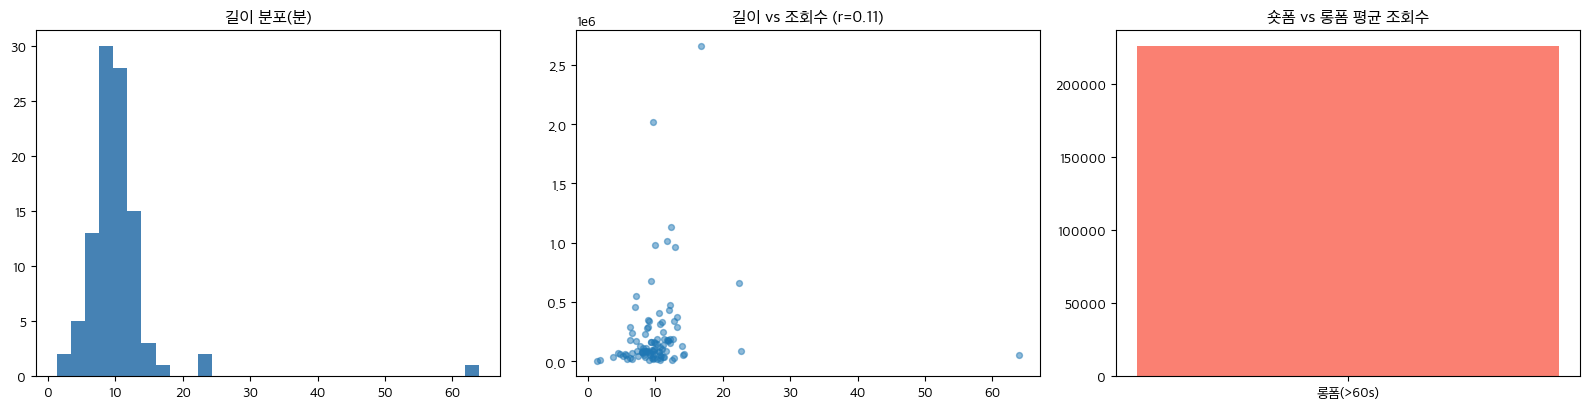

In [5]:
fig, ax = plt.subplots(1,3, figsize=(16,4.2))
ax[0].hist(df['duration_min'].dropna(), bins=30, color='steelblue'); ax[0].set_title('길이 분포(분)')
dd = df.dropna(subset=['duration_min','view_count'])
ax[1].scatter(dd['duration_min'], dd['view_count'], alpha=.5, s=18)
ax[1].set_title(f"길이 vs 조회수 (r={dd['duration_min'].corr(dd['view_count']):.2f})")
g = df.groupby('is_short')['view_count'].mean()
ax[2].bar(['롱폼','숏폼'] if False else [ '숏폼(≤60s)' if i else '롱폼(>60s)' for i in g.index], g.values,
          color=['salmon','cornflowerblue'])
ax[2].set_title('숏폼 vs 롱폼 평균 조회수')
plt.tight_layout(); plt.show()

## 4. 제목 키워드 · 장르

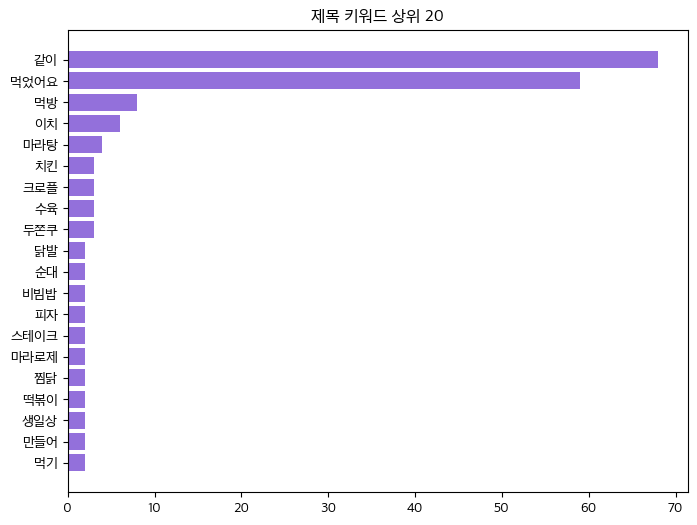

제목 길이 vs 조회수 상관계수 r = 0.012


In [6]:
tokens=[]
for t in df['title'].astype(str): tokens += kt.tokenize(t)
top = Counter(tokens).most_common(20)
w,c = zip(*top)
plt.figure(figsize=(8,6)); plt.barh(range(len(w)), c, color='mediumpurple')
plt.yticks(range(len(w)), w); plt.gca().invert_yaxis(); plt.title('제목 키워드 상위 20'); plt.show()

d = df.dropna(subset=['title_len','view_count'])
print('제목 길이 vs 조회수 상관계수 r =', round(d['title_len'].corr(d['view_count']),3))

## 5. 댓글 텍스트 마이닝

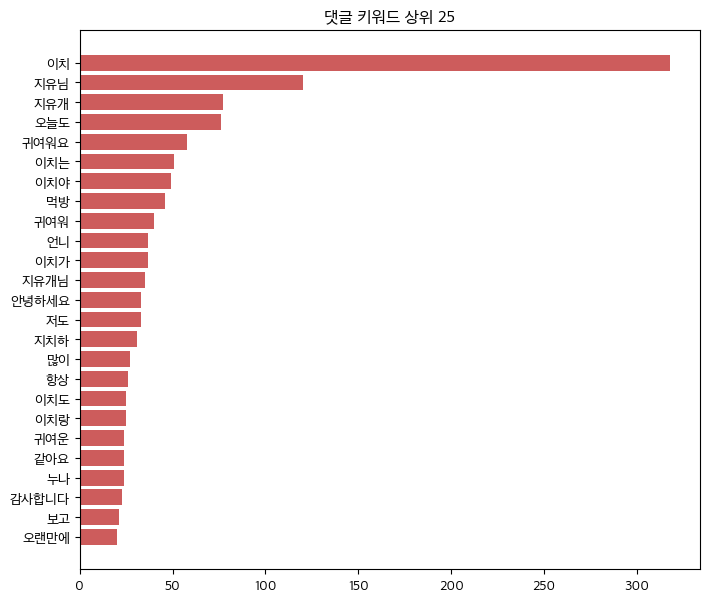

In [7]:
import os
if os.path.exists('data/comments.csv'):
    cm = pd.read_csv('data/comments.csv')
    toks=[]
    for t in cm['text'].astype(str): toks += kt.tokenize(t)
    freq = Counter(toks)
    top = freq.most_common(25); w,c = zip(*top)
    plt.figure(figsize=(8,7)); plt.barh(range(len(w)), c, color='indianred')
    plt.yticks(range(len(w)), w); plt.gca().invert_yaxis(); plt.title('댓글 키워드 상위 25'); plt.show()
else:
    print('comments.csv 없음 — collect.py 실행 시 --with-comments 옵션을 주세요.')

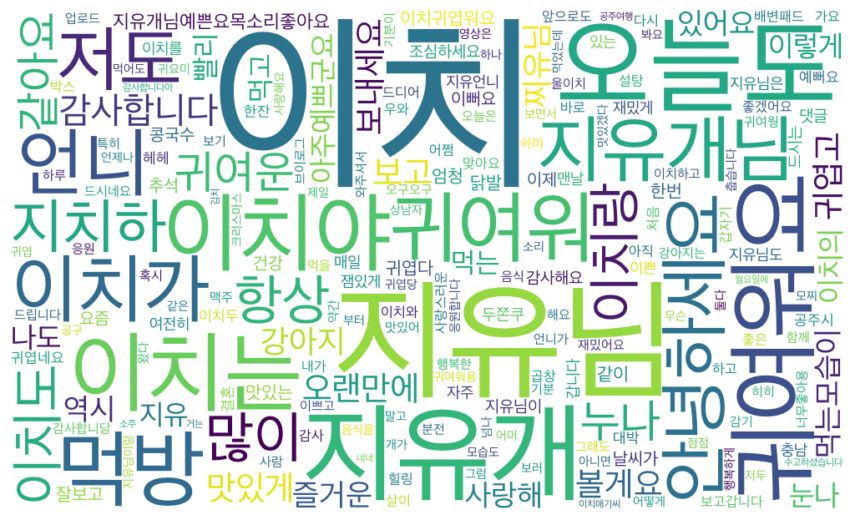

In [8]:
# 워드클라우드
from wordcloud import WordCloud
if os.path.exists('data/comments.csv') and FONT_PATH:
    wc = WordCloud(font_path=FONT_PATH, width=1000, height=600,
                   background_color='white', colormap='viridis').generate_from_frequencies(freq)
    plt.figure(figsize=(11,6.5)); plt.imshow(wc, interpolation='bilinear'); plt.axis('off'); plt.show()

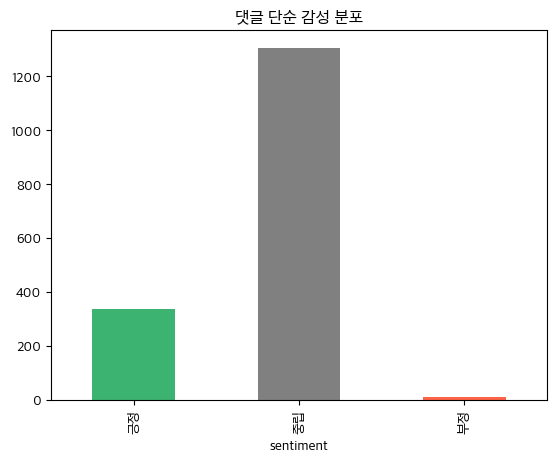

In [9]:
# 단순 감성 분포(참고용)
if os.path.exists('data/comments.csv'):
    cm['sentiment'] = cm['text'].astype(str).apply(kt.sentiment_score)
    cat = pd.cut(cm['sentiment'], bins=[-99,-1,0,99], labels=['부정','중립','긍정'])
    dist = cat.value_counts().reindex(['긍정','중립','부정'])
    dist.plot.bar(color=['mediumseagreen','gray','tomato']); plt.title('댓글 단순 감성 분포'); plt.show()

## 5-1. 긍정 / 부정 댓글 따로 분석
위 감성 분류(`cm['sentiment']`, `cm['cat']`)를 기준으로 긍정·부정 댓글을 나눠 키워드, 워드클라우드, 대표(좋아요 상위) 댓글을 비교합니다.

긍정 댓글 338개 / 부정 댓글 9개 / 전체 1653개


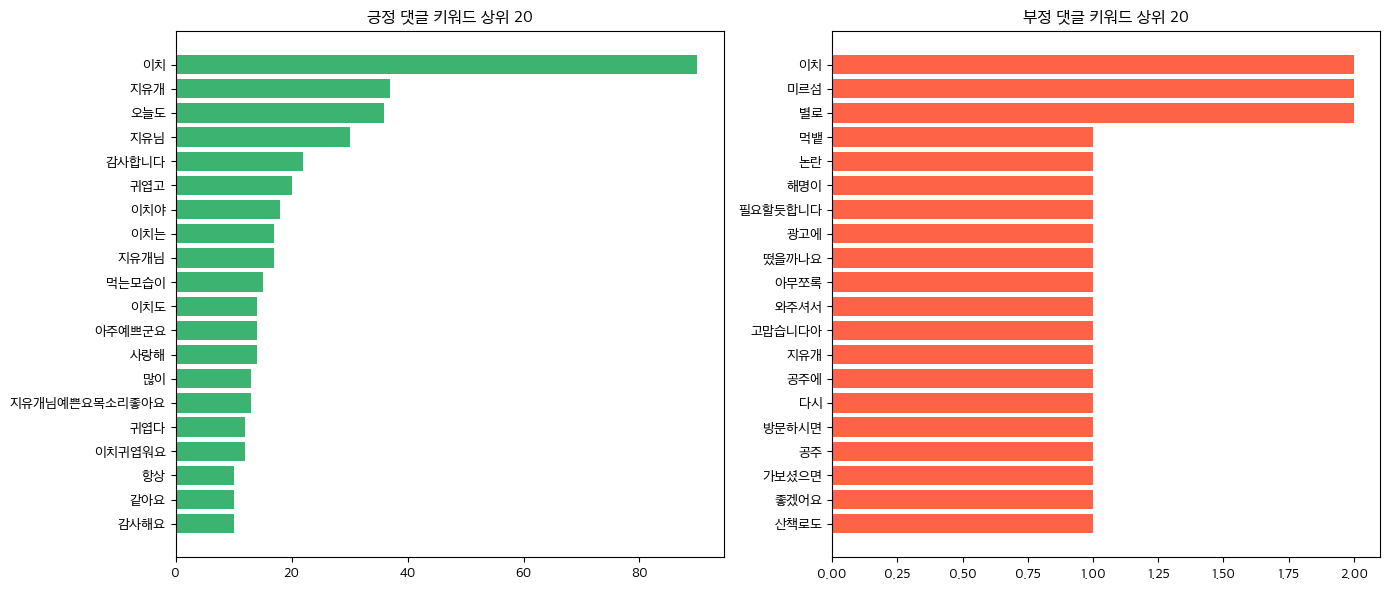

In [10]:
if os.path.exists('data/comments.csv'):
    cm = pd.read_csv('data/comments.csv')
    cm['sentiment'] = cm['text'].astype(str).apply(kt.sentiment_score)
    cm['cat'] = pd.cut(cm['sentiment'], bins=[-99,-1,0,99], labels=['부정','중립','긍정'])

    pos_df = cm[cm['cat'] == '긍정']
    neg_df = cm[cm['cat'] == '부정']
    print(f"긍정 댓글 {len(pos_df)}개 / 부정 댓글 {len(neg_df)}개 / 전체 {len(cm)}개")

    def top_keywords(texts, n=20):
        toks = []
        for t in texts.astype(str):
            toks += kt.tokenize(t)
        return Counter(toks).most_common(n)

    pos_top = top_keywords(pos_df['text'])
    neg_top = top_keywords(neg_df['text'])

    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    if pos_top:
        w, c = zip(*pos_top)
        ax[0].barh(range(len(w)), c, color='mediumseagreen')
        ax[0].set_yticks(range(len(w))); ax[0].set_yticklabels(w); ax[0].invert_yaxis()
    ax[0].set_title(f'긍정 댓글 키워드 상위 {len(pos_top)}')
    if neg_top:
        w, c = zip(*neg_top)
        ax[1].barh(range(len(w)), c, color='tomato')
        ax[1].set_yticks(range(len(w))); ax[1].set_yticklabels(w); ax[1].invert_yaxis()
    ax[1].set_title(f'부정 댓글 키워드 상위 {len(neg_top)}')
    plt.tight_layout(); plt.show()
else:
    print('comments.csv 없음 — collect.py 실행 시 --with-comments 옵션을 주세요.')

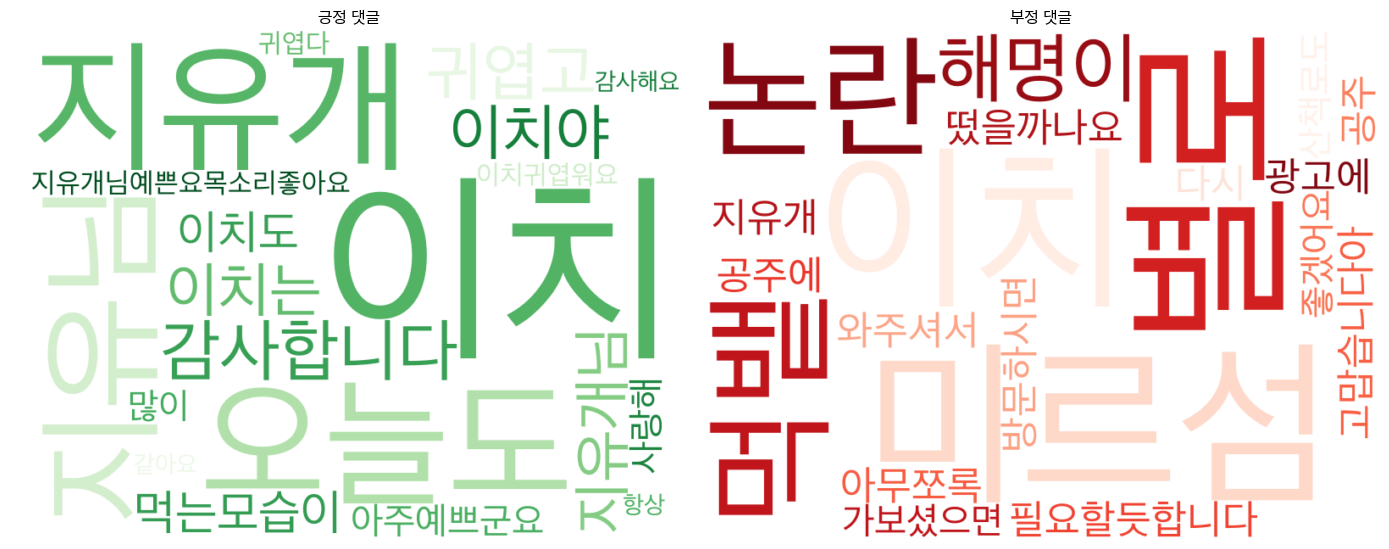

In [11]:
# 긍정/부정 워드클라우드 비교
if os.path.exists('data/comments.csv') and FONT_PATH:
    fig, ax = plt.subplots(1, 2, figsize=(14, 7))
    if pos_top:
        wc_pos = WordCloud(font_path=FONT_PATH, width=800, height=600,
                            background_color='white', colormap='Greens').generate_from_frequencies(dict(pos_top))
        ax[0].imshow(wc_pos, interpolation='bilinear')
    ax[0].axis('off'); ax[0].set_title('긍정 댓글')
    if neg_top:
        wc_neg = WordCloud(font_path=FONT_PATH, width=800, height=600,
                            background_color='white', colormap='Reds').generate_from_frequencies(dict(neg_top))
        ax[1].imshow(wc_neg, interpolation='bilinear')
    ax[1].axis('off'); ax[1].set_title('부정 댓글')
    plt.tight_layout(); plt.show()

In [12]:
# 대표 댓글 (좋아요 많은 순) — 긍정 / 부정 각 10개
if os.path.exists('data/comments.csv'):
    cols = ['video_title', 'author', 'text', 'like_count']
    print('=== 긍정 댓글 TOP 10 (좋아요 순) ===')
    display(pos_df.sort_values('like_count', ascending=False)[cols].head(10))
    print('\n=== 부정 댓글 TOP 10 (좋아요 순) ===')
    display(neg_df.sort_values('like_count', ascending=False)[cols].head(10))

=== 긍정 댓글 TOP 10 (좋아요 순) ===


,video_title,author,text,like_count
329,두쫀쿠 vs 댕쫀쿠,@hyunsookim9655,이치 두쫀쿠따라 얼굴 움직이는거 너무 귀엽,65
343,두쫀쿠 vs 댕쫀쿠,@J.제리,지치하👧🐶💚 드디어 올라왔다~~~~>_<ㅎㅎ 금손 찌유님!! 역시 역시👍 대박이예요...,52
1560,콩국수 같이 먹었어요 (콩물은 청자5호예요🍜),@껨온SON153,지유개 zziU & Ezzi님 먹는모습이 아주예쁘군요. 7월12일날에 무에타이 대회...,50
767,닭발 같이 먹었어요,@J.제리,지치하👧🐶🎀 앗 늦었다ㅜㅜ 사랑스러운 이치 ㅠㅠ🥰💕,41
641,대방어 같이 먹었어요 (Feat. 이치는 삶은 명태..),@sondmweel,이치가 몇 살인가요?... 애기가 너무 순둥순둥하고 착해서 한없이 사랑스럽네요......,22
1,곱창 같이 먹었어요,@치코ChicoTV,지유님 이치 오랜만입니다 잘먹어서 보기좋아요 이치 귀엽네요 지유님한대 달라고 하네요...,21
1184,육회 & 들기름 막국수 같이 먹었어요,@코르사1,이치 콧소리 대박!!!!너무 귀여워요 ㅎㅎㅎㅎ 면을 혀로 휘두르는거 보소ㅋㅋ 진짜 ...,21
1260,내 옷 사러 갔다가 이치 것만 잔뜩 사 온 브이로그 🛒 💸,@J.제리,지치하👩🐶❤ 와 따끈한 새영상😃 열심히 하는 모습 너무 멋지네요~~ 이치는 또 왜이...,19
1561,콩국수 같이 먹었어요 (콩물은 청자5호예요🍜),@지유개,오! 지난번에도 잘 하고 오셨나요?! 이번에도 응원할게요!! 승패를 떠나 꼭 만족하...,18
1051,엽기떡볶이 vs 엽개떡볶이,@김지연-g8r3s,안녕하세요 지유님!! 저는 도덕 선플달기를 하고있는 중1 학생입니다. 이 채널을 볼...,18



=== 부정 댓글 TOP 10 (좋아요 순) ===


,video_title,author,text,like_count
600,스테이크 같이 먹었어요,@user-hs6dr3xk3x,이치 먹뱉 논란 해명이 필요할듯합니다😅,3
961,강아지와 여행은 우리만 따라와🦊 | 네비개(犬)이션 (철원여행 편),@lovely1004_chohui,혈육놈(동생) 군부대나온 철원오랜만인데 별로안반가 웠는데 영상은반갑😂 0:33 언니...,1
1541,콩국수 같이 먹었어요 (콩물은 청자5호예요🍜),@KeyAeKR_GD,지치하🧡💙 콩국수라니! 콩국수..별로 좋아하진 않지만 그래도 먹긴합니당😅 오늘도 광...,1
845,미슐랭 vs 개슐랭 | 네비개(犬)이션 (공주여행 편),@지유개,광고에 떴을까나요?? 아무쪼록 와주셔서 고맙습니다아 😊,0
875,미슐랭 vs 개슐랭 | 네비개(犬)이션 (공주여행 편),@k1y-h1u,@지유개 공주에 다시 방문하시면 공주 미르섬 꼭 가보셨으면 좋겠어요! 산책로도 너...,0
1134,엽기떡볶이 vs 엽개떡볶이,@지율이세상,로제 착한맛은 별로 안 매워유 참고해 보세용,0
1567,콩국수 같이 먹었어요 (콩물은 청자5호예요🍜),@이희경-g5v,아~오ㅋ 증말ㅋ 이치개짜증ㅋㅋ😂😂😂,0
1634,콩국수 같이 먹었어요 (콩물은 청자5호예요🍜),@thinkingirl616,앗 2분만 빨리올걸 아쉽네요,0
1643,콩국수 같이 먹었어요 (콩물은 청자5호예요🍜),@타오르는토마토,실망입니다. 설탕파라니 7:35 한국어를 알아 듣는거 같은디,0


---
### 한 번에 전체 리포트 만들기
아래 한 줄로 `output/` 폴더에 모든 차트 + `summary.md`가 저장됩니다.

In [13]:
!python analyze.py

데이터 로드...


  영상 100건
1) 조회수 시계열


  저장: 01_timeseries.png
2) 영상 길이


  저장: 02_duration.png
3) 제목·장르


  저장: 03_titles.png


  저장: 04_title_length.png
4) 댓글 텍스트 마이닝


  저장: 05_comment_keywords.png


  저장: 06_comment_wordcloud.png


  저장: 07_comment_sentiment.png
요약 작성
  저장: summary.md

완료 → /Users/igyeonglog/Library/Application Support/Claude/local-agent-mode-sessions/270ae56f-9722-4ffd-9b85-16d0468db5b9/666f91a5-9d3e-4fed-a249-0c4672d9a24d/local_0bd530ff-30f8-42b7-b165-de5375ebfba2/outputs/youtube_channel_analysis/output
